# PHASE 1

## Layer 1 - Dedup

In [157]:
from dateutil.parser import parse
import networkx as nx
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from dateutil.parser import parse
import json

In [158]:
# finger print

def fingerprint(alert: dict) -> str:
    return f"{alert['service']}|{alert['metric']}|{alert['severity']}"


In [159]:
# Deduper --
class Deduper:
    def __init__(self):
        self.store: dict[str, dict] = {}

    def push(self, alert: dict) -> str:
        fp = fingerprint(alert)
        if fp not in self.store:
            self.store[fp] = {
                'cluster_id': fp,
                'count': 1,
                'first_seen': alert['ts'],
                'last_seen': alert['ts'],
                'alerts': [alert['id']],
            }
        else:
            c = self.store[fp]
            c['count'] += 1
            c['last_seen'] = alert['ts']
            c['alerts'].append(alert['id'])
        return fp


## Layer 2 - Time window

In [160]:
# session window

def session_groups(alerts: list[dict], gap_sec: int = 120) -> list[list[dict]]:
    """Mỗi group là 1 'session'. Session ngắt khi gap > gap_sec giây."""
    if not alerts:
        return []
    sorted_alerts = sorted(alerts, key=lambda a: a['ts'])
    groups = [[sorted_alerts[0]]]
    for alert in sorted_alerts[1:]:
        last_ts = parse(groups[-1][-1]['ts'])
        if (parse(alert['ts']) - last_ts).total_seconds() <= gap_sec:
            groups[-1].append(alert)
        else:
            groups.append([alert])
    return groups


## Layer 3 - Topology

In [161]:
def topology_group(alerts, graph, max_hop=2):
    """Gom alert có service cách nhau ≤ max_hop trên graph."""
    undirected = graph.to_undirected()
    by_service = defaultdict(list)
    for a in alerts:
        by_service[a['service']].append(a)

    services = list(by_service.keys())
    parent = {s: s for s in services}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for i, s1 in enumerate(services):
        for s2 in services[i+1:]:
            try:
                if nx.shortest_path_length(undirected, s1, s2) <= max_hop:
                    parent[find(s1)] = find(s2)
            except nx.NetworkXNoPath:
                pass

    groups = defaultdict(list)
    for s in services:
        groups[find(s)].extend(by_service[s])
    return list(groups.values())



In [162]:
# Kết họp time window, topoogy

def correlate(alerts, graph, gap_sec=120, max_hop=2):
    sessions = session_groups(alerts, gap_sec=gap_sec)
    clusters = []
    for s_idx, session_alerts in enumerate(sessions):
        for g_idx, group in enumerate(topology_group(session_alerts, graph, max_hop)):
            clusters.append({
                'cluster_id': f'c-{s_idx:03d}-{g_idx:03d}',
                'alert_count': len(group),
                'services': sorted({a['service'] for a in group}),
                'time_range': [min(a['ts'] for a in group), max(a['ts'] for a in group)],
                'max_severity': max(a['severity'] for a in group),
                #'alert_ids': [a['id'] for a in group],
                "fingerprints": sorted(set(fingerprint(a) for a in group))
            })
    return clusters


# Layer 4 - Semantic Similarity

In [163]:
def text_similarity(a, b) -> float:
    def tokens(x):
        text = f"{x['metric']} {x.get('labels', {}).get('note', '')}"
        return set(text.lower().replace('_', ' ').split())
    ta, tb = tokens(a), tokens(b)
    return len(ta & tb) / len(ta | tb) if ta and tb else 0.0


# Build correlator

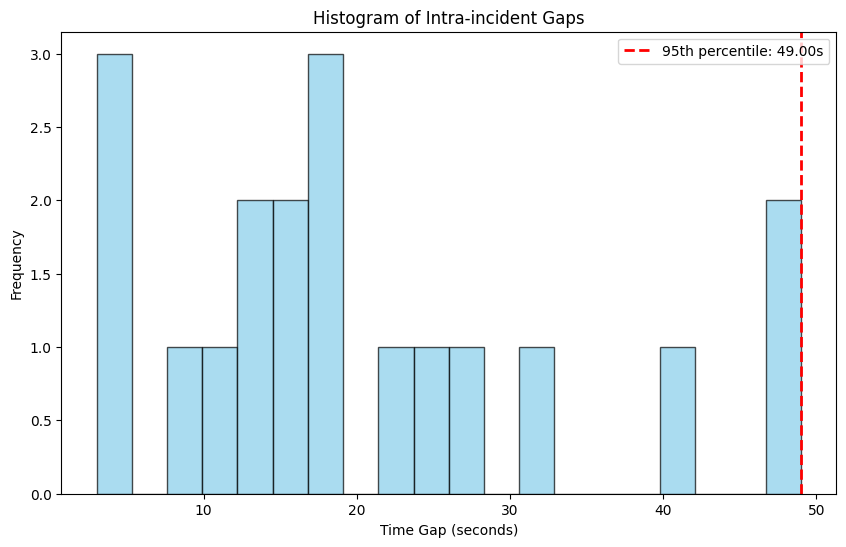

Recommended gap_sec = 49.00


In [164]:
def calculate_optimal_gap(alerts):
    timestamps = sorted([parse(a['ts']) for a in alerts])
    
    gap_sec = [(timestamps[i+1] - timestamps[i]).total_seconds() for i in range(len(timestamps)-1)]
    p95 = np.percentile(gap_sec, 95)
    
    plt.figure(figsize=(10, 6))
    plt.hist(gap_sec, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(p95, color='red', linestyle='dashed', linewidth=2, label=f'95th percentile: {p95:.2f}s')
    
    plt.title('Histogram of Intra-incident Gaps')
    plt.xlabel('Time Gap (seconds)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
    return p95

optimal_gap_sec = calculate_optimal_gap(alerts)
print(f"Recommended gap_sec = {optimal_gap_sec:.2f}")

In [165]:
# load data
with open('dataset/services.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
    
    G = nx.DiGraph()
    
    for s in data['services']:
        G.add_node(s['name'], type='service')
    for s in data['stores']:
        G.add_node(s['name'], type='store')
        
    for edge in data['edges']:
        G.add_edge(edge['from'], edge['to'], type=edge['type'])

with open('dataset/alerts_sample.jsonl', 'r') as f:
    alerts = [json.loads(line) for line in f]
    
print("service: ",data)

print("Alerts: ",alerts)

service:  {'_meta': {'scenario': "Synthetic e-commerce platform 'GeekShop'. 10 services + 2 backing stores. Map sang NAB metric streams + HDFS log slice của W1.", 'schema_version': '1.0', 'generated_for': 'AIOps W2 group lab (Thu Jun 11 - Fri Jun 12, 2026)', 'nab_mapping': 'Mỗi service có 1 NAB stream gán cố định cho metric latency. CPU/memory derive bằng cách thêm noise + shift baseline.'}, 'services': [{'name': 'edge-lb', 'tier': 'edge', 'team': 'platform', 'owner_pager': 'platform-oncall', 'criticality': 'high', 'nab_stream': 'realKnownCause/ec2_request_latency_system_failure.csv'}, {'name': 'auth-svc', 'tier': 'api', 'team': 'identity', 'owner_pager': 'identity-oncall', 'criticality': 'high', 'nab_stream': 'realKnownCause/ambient_temperature_system_failure.csv'}, {'name': 'checkout-svc', 'tier': 'api', 'team': 'checkout', 'owner_pager': 'checkout-oncall', 'criticality': 'high', 'nab_stream': 'realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv'}, {'name': 'payment-svc', 'tier': 'api',

In [166]:
# run correlation
clusters = correlate(alerts, G, gap_sec=49, max_hop=1)
output = {
    "input_alerts": len(alerts),
    "output_clusters": len(clusters),
    "reduction_ratio": 1 - (len(clusters) / len(alerts)),
    "clusters": clusters
}

import os
os.makedirs('results', exist_ok=True)
with open('results/cluster_summary.json', 'w') as f:
    json.dump(output, f, indent=2)

print(output)

{'input_alerts': 20, 'output_clusters': 2, 'reduction_ratio': 0.9, 'clusters': [{'cluster_id': 'c-000-000', 'alert_count': 19, 'services': ['cart-svc', 'checkout-svc', 'edge-lb', 'notification-svc', 'payment-svc', 'search-svc'], 'time_range': ['2026-06-12T09:42:01Z', '2026-06-12T09:48:30Z'], 'max_severity': 'warn', 'fingerprints': ['cart-svc|latency_p99_ms|warn', 'checkout-svc|downstream_payment_error_rate|crit', 'checkout-svc|latency_p99_ms|crit', 'checkout-svc|latency_p99_ms|warn', 'checkout-svc|request_drop_rate|crit', 'edge-lb|p99_latency_ms|crit', 'edge-lb|upstream_5xx_rate|crit', 'edge-lb|upstream_5xx_rate|warn', 'notification-svc|queue_depth|crit', 'notification-svc|queue_lag_ms|warn', 'payment-svc|db_connection_pool_used_ratio|crit', 'payment-svc|db_connection_pool_used_ratio|warn', 'payment-svc|error_rate|crit', 'payment-svc|error_rate|warn', 'payment-svc|latency_p99_ms|crit', 'search-svc|catalog_db_query_time_ms|warn']}, {'cluster_id': 'c-000-001', 'alert_count': 1, 'services